<a href="https://colab.research.google.com/github/varshitfauzdar/AIH_Lab_work/blob/main/Lab1_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn wfdb pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

import wfdb

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

file_path = "processed.cleveland.data"

urllib.request.urlretrieve(url, file_path)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [ ]:
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    file_path,
    names=columns,
    na_values="?"
)

print(df.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [ ]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

In [ ]:
df["target"] = df["target"].apply(
    lambda x: 0 if x == 0 else 1
)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing numerical values using median
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


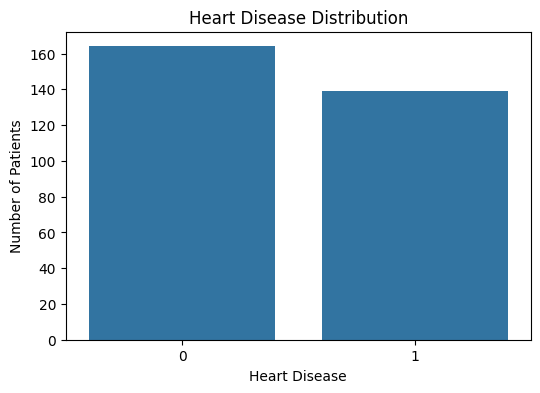

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

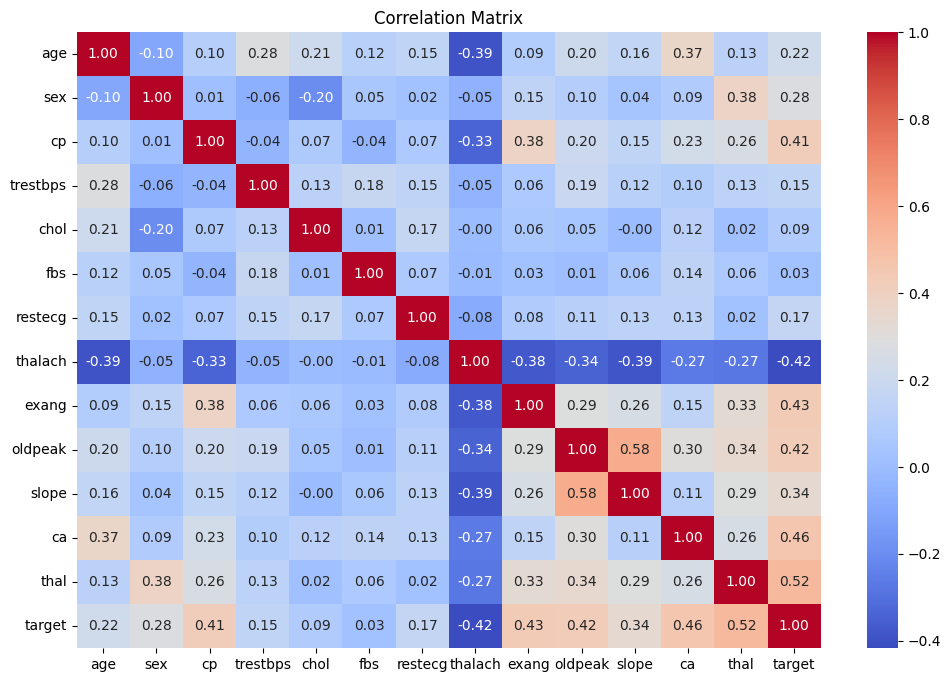

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8689
ROC-AUC: 0.9513

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



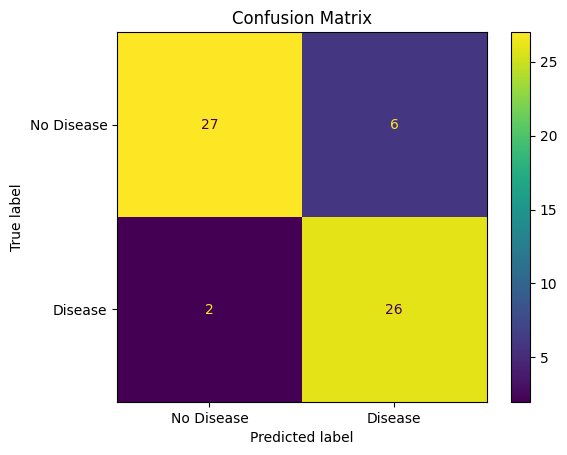

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

#SIGNAL DATA — MIT-BIH ECG

In [ ]:
record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("Record loaded successfully.")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(annotation.sample))

Record loaded successfully.
Signal shape: (650000, 2)
Sampling frequency: 360
Number of annotations: 2274


In [ ]:
print("Sampling frequency:", record.fs, "Hz")

print("Number of channels:", record.n_sig)

print("Channel names:", record.sig_name)

print("Signal length:", record.sig_len)

Sampling frequency: 360 Hz
Number of channels: 2
Channel names: ['MLII', 'V5']
Signal length: 650000


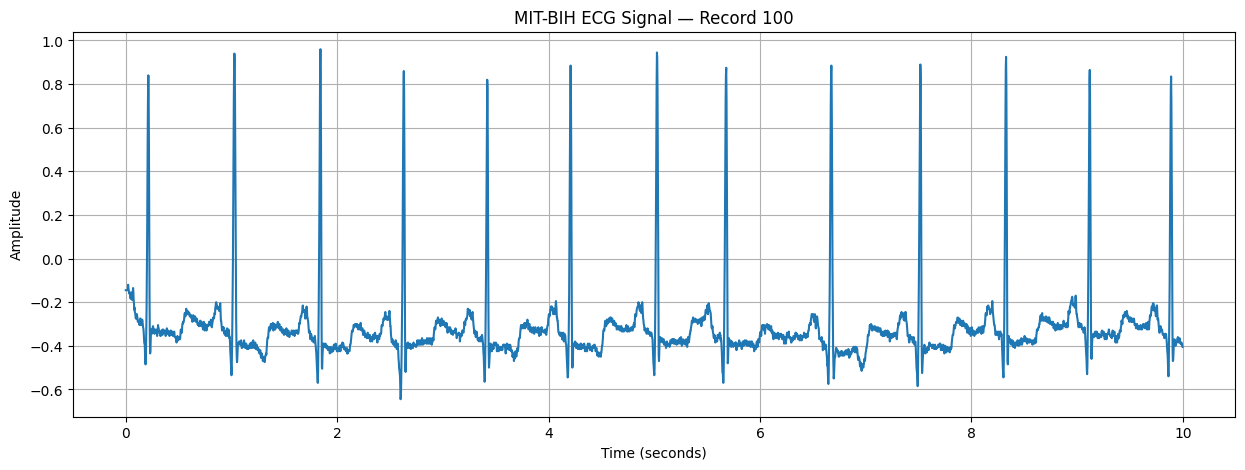

In [ ]:
fs = record.fs

seconds = 10

samples = int(fs * seconds)

ecg_signal = record.p_signal[:samples, 0]

time = np.arange(samples) / fs

plt.figure(figsize=(15, 5))

plt.plot(time, ecg_signal)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Signal — Record 100")

plt.grid()

plt.show()

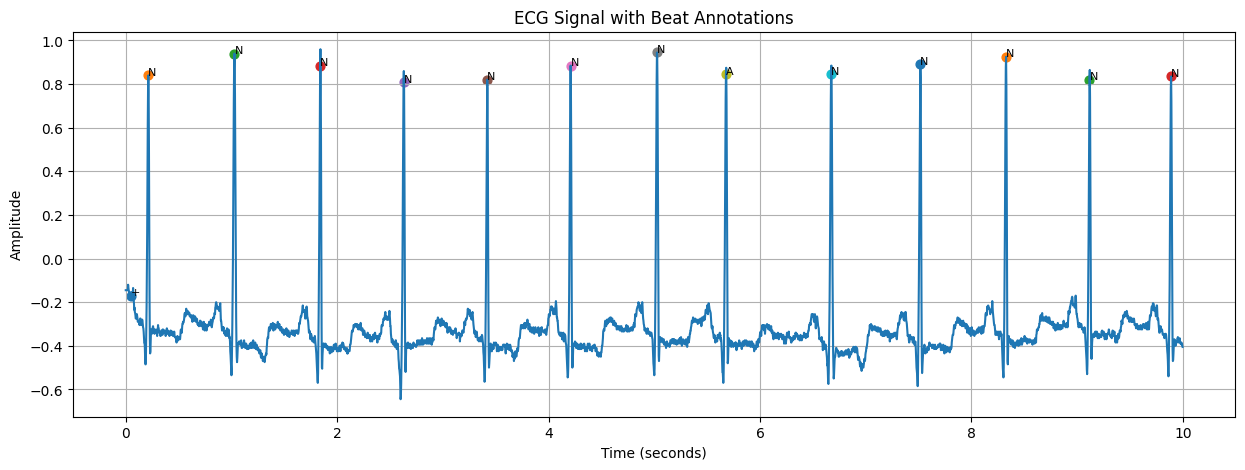

In [ ]:
annotation_samples = annotation.sample[
    annotation.sample < samples
]

annotation_symbols = [
    annotation.symbol[i]
    for i, sample in enumerate(annotation.sample)
    if sample < samples
]

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal,
    label="ECG Signal"
)

for sample, symbol in zip(
    annotation_samples,
    annotation_symbols
):

    plt.scatter(
        sample / fs,
        ecg_signal[sample],
        s=40
    )

    plt.text(
        sample / fs,
        ecg_signal[sample],
        symbol,
        fontsize=8
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.grid()

plt.show()

In [ ]:
# Use annotation locations as approximate heartbeat locations

beat_samples = annotation.sample

rr_intervals = np.diff(beat_samples) / fs

print("First 20 RR intervals:")
print(rr_intervals[:20])

print("\nAverage RR interval:",
      round(np.mean(rr_intervals), 3),
      "seconds")

First 20 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444 0.81111111 0.78888889
 0.77222222 0.83888889 0.85555556 0.82222222 0.82777778 0.82222222
 0.79444444 0.79722222]

Average RR interval: 0.794 seconds


In [ ]:
average_rr = np.mean(rr_intervals)

heart_rate = 60 / average_rr

print(
    "Estimated Average Heart Rate:",
    round(heart_rate, 2),
    "BPM"
)

Estimated Average Heart Rate: 75.54 BPM


In [ ]:
sdnn = np.std(rr_intervals)

print("Number of RR intervals:", len(rr_intervals))
print("Mean RR:", round(np.mean(rr_intervals), 4), "seconds")
print("SDNN:", round(sdnn, 4), "seconds")
print("Minimum RR:", round(np.min(rr_intervals), 4), "seconds")
print("Maximum RR:", round(np.max(rr_intervals), 4), "seconds")

Number of RR intervals: 2273
Mean RR: 0.7943 seconds
SDNN: 0.0506 seconds
Minimum RR: 0.1639 seconds
Maximum RR: 1.1306 seconds


In [ ]:
clinical_note = """
Patient is a 55 year old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient experiences shortness of breath.
ECG examination is recommended.
The patient has a history of high cholesterol.
"""

print(clinical_note)


Patient is a 55 year old male.
The patient reports chest pain during physical activity.
Blood pressure is elevated.
The patient experiences shortness of breath.
ECG examination is recommended.
The patient has a history of high cholesterol.



In [ ]:
import re

text = clinical_note.lower()

# Remove punctuation
clean_text = re.sub(r"[^a-zA-Z\s]", "", text)

# Split into words
words = clean_text.split()

print("Cleaned text:")
print(clean_text)

print("\nWords:")
print(words)

Cleaned text:

patient is a  year old male
the patient reports chest pain during physical activity
blood pressure is elevated
the patient experiences shortness of breath
ecg examination is recommended
the patient has a history of high cholesterol


Words:
['patient', 'is', 'a', 'year', 'old', 'male', 'the', 'patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'experiences', 'shortness', 'of', 'breath', 'ecg', 'examination', 'is', 'recommended', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'cholesterol']


In [ ]:
word_frequency = Counter(words)

print("Word Frequency:")

for word, count in word_frequency.most_common():
    print(word, ":", count)

Word Frequency:
patient : 4
is : 3
the : 3
a : 2
of : 2
year : 1
old : 1
male : 1
reports : 1
chest : 1
pain : 1
during : 1
physical : 1
activity : 1
blood : 1
pressure : 1
elevated : 1
experiences : 1
shortness : 1
breath : 1
ecg : 1
examination : 1
recommended : 1
has : 1
history : 1
high : 1
cholesterol : 1


In [ ]:
stopwords = {
    "the", "is", "a", "an", "of",
    "and", "to", "during", "has",
    "with", "in", "on"
}

filtered_words = [
    word for word in words
    if word not in stopwords
]

print("Filtered words:")
print(filtered_words)

Filtered words:
['patient', 'year', 'old', 'male', 'patient', 'reports', 'chest', 'pain', 'physical', 'activity', 'blood', 'pressure', 'elevated', 'patient', 'experiences', 'shortness', 'breath', 'ecg', 'examination', 'recommended', 'patient', 'history', 'high', 'cholesterol']


In [ ]:
from PIL import Image, ImageDraw

image = Image.new(
    "L",
    (512, 512),
    color=0
)

draw = ImageDraw.Draw(image)

# Create two circular regions representing lungs
draw.ellipse(
    (80, 80, 240, 430),
    fill=180
)

draw.ellipse(
    (272, 80, 432, 430),
    fill=180
)

# Add central region
draw.rectangle(
    (245, 150, 267, 400),
    fill=100
)

image.save("synthetic_chest_xray.png")

print("Synthetic medical image created.")

Synthetic medical image created.


In [ ]:
img = Image.open("synthetic_chest_xray.png")

print("Image format:", img.format)
print("Image size:", img.size)
print("Image mode:", img.mode)

Image format: PNG
Image size: (512, 512)
Image mode: L


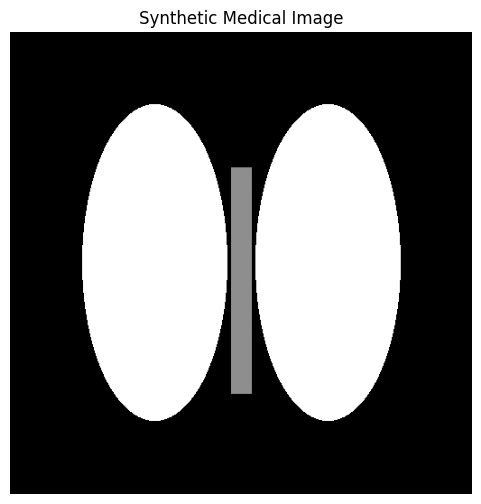

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(img, cmap="gray")

plt.title("Synthetic Medical Image")

plt.axis("off")

plt.show()

In [ ]:
32